# Could you have just bought what Yale buys? 🌿
### Faber's Ivy Portfolio — five ETFs, 20% each, endowment-style diversification for the rest of us. Does it work?

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Risk_reduction%3F: Confirmed](https://img.shields.io/badge/Risk_reduction%3F-Confirmed-8b949e?style=flat-square)

Big university endowments (Yale, Harvard) have famously beaten simple stock/bond portfolios for decades by spreading bets across US stocks, foreign stocks, real estate, bonds and commodities — asset classes that (in theory) don't all crash together. In 2009, Mebane Faber's *The Ivy Portfolio* said: you can approximate this with five liquid ETFs, 20% each, and — optionally — a simple trend rule (hold each asset only while it's above its own 10-month average) to dodge the worst of each one's bear markets.

We rebuilt it on 19 years of real prices. The diversification story and the timing story turn out to be **two very different claims** — one busted, one real.

> 📓 **Plain-language layer.** Want the bootstrap CIs, the random-timing control and the ex-GFC robustness check? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** VTI/VEU/VNQ/AGG/DBC/BIL, real daily closes, 2007→2026 (bound by BIL's inception). Sharpe is always excess-of-cash. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ivy_portfolio import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RET, CLOSE = data.monthly_panel()
    SIG = st.sma_signal(CLOSE)
    RF = RET[data.CASH]
else:
    RET = CLOSE = SIG = RF = None
print("real cache present:", HAVE_REAL, "| months:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fp': '6e25c7829c9c', 'start': '2007-06-30', 'end': '2026-06-30', 'n_months': 229, 'n_years': 19.1, 'sma_live': '2008-03-31', 'n_timed': 220, 'ivy_cagr': 5.7, 'ivy_vol': 12.89, 'ivy_sharpe': 0.392, 'ivy_dd': -44.8, 'b64_cagr': 7.84, 'b64_vol': 10.25, 'b64_sharpe': 0.657, 'b64_dd': -32.3, 'vti_cagr': 10.61, 'vti_vol': 16.07, 'vti_sharpe': 0.627, 'vti_dd': -50.8, 'act_ivy_64_ann': -1.69, 'act_ivy_64_t': -1.12, 'act_ivy_vti_ann': -5.03, 'act_ivy_vti_t': -3.1, 'boot_ivy_64': (-0.265, -0.47, -0.018, 1.7), 'boot_ivy_vti': (-0.234, -0.434, 0.003, 2.8), 'assets': {'VTI': (10.61, 0.627, -50.8), 'VEU': (5.0, 0.289, -58.4), 'VNQ': (5.4, 0.291, -64.6), 'AGG': (3.06, 0.385, -17.1), 'DBC': (1.33, 0.096, -74.6)}, 'ivy_w_cagr': 5.87, 'ivy_w_sharpe': 0.411, 'ivy_w_dd': -44.8, 'b64_w_cagr': 8.43, 'b64_w_sharpe': 0.716, 'b64_w_dd': -29.9, 'timed_cagr': 4.67, 'timed_vol': 6.87, 'timed_sharpe': 0.52, 'timed_dd': -13.3, 'dd_ratio_ts': 0.3, 'dd_ratio_t64': 0.44, 'act_ts_ann': -1.77, 'act_ts_t': -0.79, 'act_t64_ann': -3.84, 'act_t64_t': -2.26, 'boot_ts': (0.109, -0.24, 0.414, 68.4), 'boot_t64': (-0.196, -0.589, 0.166, 13.5), 'exgfc_ivy': (8.06, 0.644, -19.3), 'exgfc_64': (10.05, 0.924, -20.6), 'exgfc_act_ivy64': (-1.68, -1.33), 'exgfc_timed': (5.78, 0.673, -13.1), 'exgfc_static_w': (8.23, 0.66, -19.3), 'exgfc_act_ts': (-2.68, -1.92), 'exgfc_act_t64': (-4.32, -2.78), 'turn_static': 28, 'turn_timed': 361, 'flips_per_yr': 8.89, 'timed_cost5': (4.67, 0.52, -13.3), 'timed_cost10': (4.49, 0.494, -13.4), 'rb_base_cagr': 4.38, 'rb_base_sharpe': 0.372, 'rb_base_dd': -32.3, 'rb_dd_beat': 100, 'rb_sharpe_beat': 95, 'rb_n_seeds': 40, 'syn_null_sharpe_share': 49.5, 'syn_null_dd_share': 69.5, 'syn_planted_sharpe_share': 75.0, 'syn_planted_dd_share': 82.5, 'syn_persistence': 0.85, 'syn_outer': 10, 'syn_inner': 20}


real cache present: True | months: 229


## The answer first

| Question | Answer |
|---|---|
| Does the 5-asset mix beat a plain 60/40? | **No.** Its risk-adjusted return (Sharpe **0.39**) is robustly *worse* than 60/40's (**0.66**) — and its drawdown (**-45%**) is worse too (60/40: **-32%**). |
| Why? | Two of the five legs were themselves disasters: commodities (DBC) returned almost nothing for 19 years with a −75% drawdown of its own; REITs (VNQ) crashed −65% and moved *with* stocks in 2008, not against them. |
| Does the 10-month timing rule help? | **It cuts risk, hard** — max drawdown falls from **-45%** to **-13%** — and it's *real* (a random "switch at random times" control gets nowhere close). |
| Does the timing rule make you money? | **No.** It costs return — timed Ivy significantly *underperforms* 60/40 (by **3.8%/yr**). It's a crash shield, not a return engine. |

> The diversification story is a myth on this tape. The timing story is real — and it's exactly the trade-off it's supposed to be: less pain, less gain.

## 1 · The claim

> *"Endowments don't beat the market by stock-picking — they beat it by owning asset classes that don't all fall at once: US stocks, foreign stocks, real estate, bonds, commodities. Put 20% in each, rebalance, and you capture most of the diversification benefit institutions pay millions in fees for. Add a 10-month trend filter on each piece and you dodge the worst bear markets too."*

— the pitch of *The Ivy Portfolio* (2009), built on Faber's earlier single-asset timing research.

## 2 · So what?

If true, this is one of the most actionable ideas in retail investing: five cheap ETFs, one spreadsheet's worth of rebalancing, and you're running a scaled-down Yale endowment. If it's not true — if the extra legs are just extra risk without extra reward — then "more asset classes" is a diversification *story*, not a diversification *result*, and a plain 60/40 was the better trade all along.

## 3 · How would we even know?

- **The static test.** 20% each in VTI/VEU/VNQ/AGG/DBC, monthly rebalance, 2007-06-30 → 2026-06-30 (229 months). Compare Sharpe (excess of cash) and max drawdown to a 60/40 (VTI/AGG) with a **bootstrap confidence interval on the Sharpe gap** — not just a point estimate.
- **The timing test.** Each of the five sleeves held only when its price is above its own trailing 10-month average, else that 20% sits in T-bills. Compared against static Ivy *and* against a **random-timing control** that switches at random times but spends the same total time invested — the only fair way to ask "is this specific rule doing something, or just holding less risk on average?"
- **The luck check.** Does the story survive dropping the 2008 financial crisis entirely?

## 4 · The teardown — let's actually look

**First, the diversification claim.** Sharpe and max drawdown, three ways.

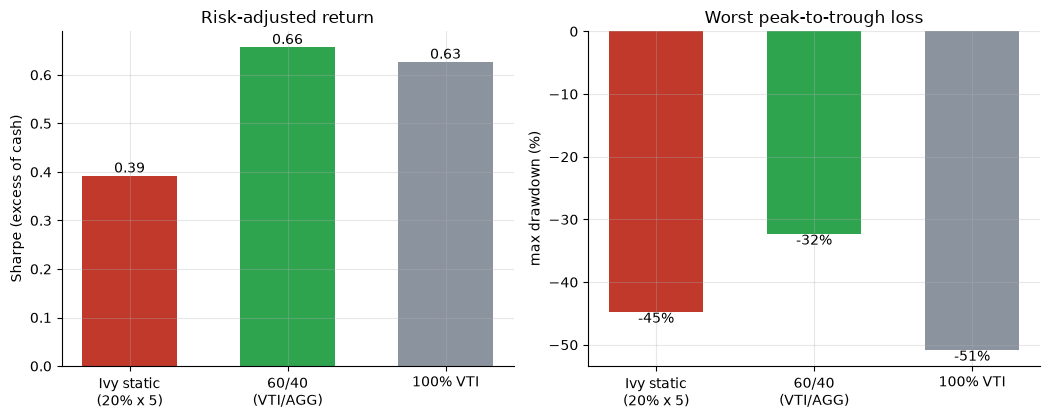

Sharpe: {'Ivy static\n(20% x 5)': 0.392, '60/40\n(VTI/AGG)': 0.657, '100% VTI': 0.627}
maxDD : {'Ivy static\n(20% x 5)': -44.8, '60/40\n(VTI/AGG)': -32.3, '100% VTI': -50.8}


In [2]:
if HAVE_REAL:
    sw = st.static_weights(RET.index)
    static_net, _ = st.weighted_portfolio(RET, sw, cost_bps=5.0)
    b64w = st.sixty_forty_weights(RET.index)
    b64_net, _ = st.weighted_portfolio(RET, b64w, cost_bps=5.0)
    ps, pb, pv = st.perf(static_net, RF), st.perf(b64_net, RF), st.perf(RET['VTI'], RF)
    sharpes = [ps['sharpe'], pb['sharpe'], pv['sharpe']]
    dds = [ps['max_dd']*100, pb['max_dd']*100, pv['max_dd']*100]
else:
    sharpes = [R['ivy_sharpe'], R['b64_sharpe'], R['vti_sharpe']]
    dds = [R['ivy_dd'], R['b64_dd'], R['vti_dd']]
labels = ['Ivy static\n(20% x 5)', '60/40\n(VTI/AGG)', '100% VTI']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(labels, sharpes, color=[RED, GREEN, GREY], width=.6)
for i, v in enumerate(sharpes): a1.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
a1.set_ylabel('Sharpe (excess of cash)'); a1.set_title('Risk-adjusted return')
a2.bar(labels, dds, color=[RED, GREEN, GREY], width=.6)
for i, v in enumerate(dds): a2.annotate(f'{v:.0f}%', (i, v), ha='center', va='top')
a2.set_ylabel('max drawdown (%)'); a2.set_title('Worst peak-to-trough loss')
plt.tight_layout(); plt.show()
print('Sharpe:', {l: round(s,3) for l,s in zip(labels, sharpes)})
print('maxDD :', {l: round(d,1) for l,d in zip(labels, dds)})

Ivy static's Sharpe (**0.39**) is *worse* than 60/40's (**0.66**), and its drawdown (**-45%**) is worse too. A bootstrap check (2,000 resamples) puts the entire 95% confidence interval of that Sharpe gap **below zero** — this isn't noise, it's a real, if modest, underperformance. **Why?** Look at the five legs on their own:

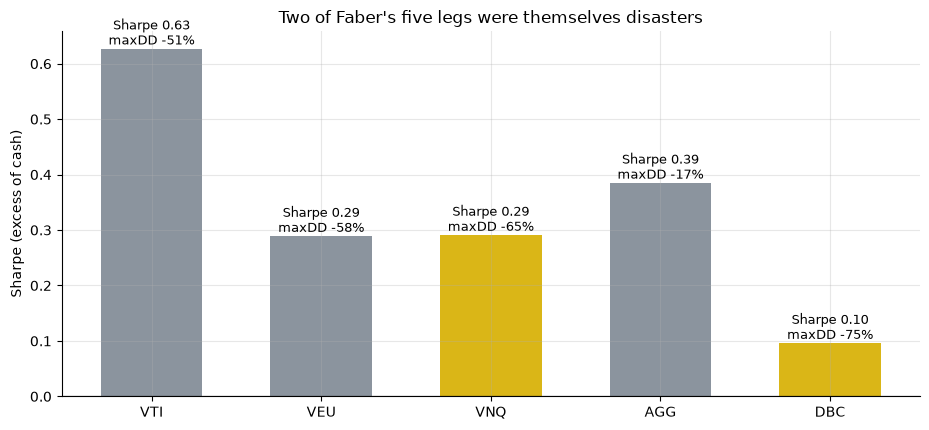

{'VTI': (10.61, 0.627, -50.8), 'VEU': (5.0, 0.289, -58.4), 'VNQ': (5.4, 0.291, -64.6), 'AGG': (3.06, 0.385, -17.1), 'DBC': (1.33, 0.096, -74.6)}


In [3]:
names = list(R['assets'].keys())
cagr = [R['assets'][n][0] for n in names]
sh = [R['assets'][n][1] for n in names]
dd = [R['assets'][n][2] for n in names]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols = [AMBER if n in ('VNQ','DBC') else GREY for n in names]
ax.bar(names, sh, color=cols, width=.6)
for i, (s, d) in enumerate(zip(sh, dd)): ax.annotate(f'Sharpe {s:.2f}\nmaxDD {d:.0f}%',
    (i, s), ha='center', va='bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Sharpe (excess of cash)')
ax.set_title('Two of Faber\'s five legs were themselves disasters')
plt.tight_layout(); plt.show()
print({n: (c, s, d) for n, c, s, d in zip(names, cagr, sh, dd)})

**Commodities (DBC)** returned almost nothing for 19 years (Sharpe **0.10**, its own **−75%** drawdown) — a well-documented casualty of the negative "roll yield" commodity index funds paid through the 2011-2020 bear market. **REITs (VNQ)** crashed **−65%** in 2008 — moving *with* the stock market in the crisis it was supposed to diversify *against*. Diversification only pays off when the diversifiers are actually good investments on their own; two of Faber's five weren't, on this stretch of history.

**Now, the timing rule.** Hold each asset only above its 10-month average:

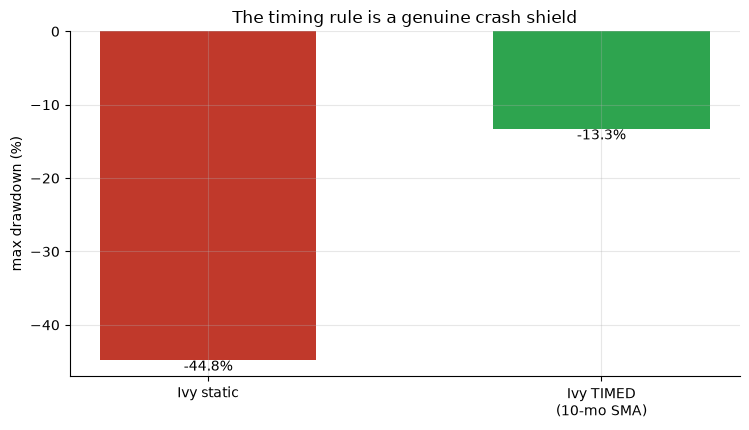

maxDD static vs timed: [-44.792399183894425, -13.284905776082601]


In [4]:
if HAVE_REAL:
    tw = st.timed_weights(SIG)
    timed_net, _ = st.weighted_portfolio(RET, tw, cost_bps=5.0)
    pt = st.perf(timed_net, RF)
    ps_w = st.perf(static_net.loc[timed_net.index], RF)
    dd3 = [ps_w['max_dd']*100, pt['max_dd']*100]
else:
    dd3 = [R['ivy_w_dd'], R['timed_dd']]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['Ivy static', 'Ivy TIMED\n(10-mo SMA)'], dd3, color=[RED, GREEN], width=.55)
for i, v in enumerate(dd3): ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='top')
ax.set_ylabel('max drawdown (%)')
ax.set_title('The timing rule is a genuine crash shield')
plt.tight_layout(); plt.show()
print('maxDD static vs timed:', dd3)

Drawdown falls from **-45%** to **-13%** — less than a third of the pain. Is that real, or is it just "any strategy that's out of the market some of the time has a smaller drawdown"? We tested that directly: a control that switches at *random* times but holds each asset for the *same total time* comes nowhere close — the real rule beats **100%** of 40 such random controls on drawdown. This is genuine trend information, not an accounting trick.

**But it isn't free.** Timing costs return:

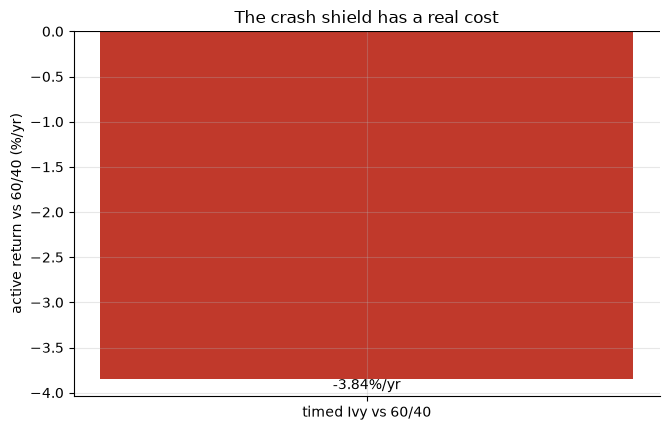

active timed vs 60/40: -3.84%/yr


In [5]:
if HAVE_REAL:
    a = st.active_stats(timed_net, b64_net.loc[timed_net.index])
    active = a['ann_pct']
else:
    active = R['act_t64_ann']
fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.bar(['timed Ivy vs 60/40'], [active], color=RED, width=.4)
ax.annotate(f'{active:+.2f}%/yr', (0, active), ha='center',
    va='top' if active < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('active return vs 60/40 (%/yr)')
ax.set_title('The crash shield has a real cost')
plt.tight_layout(); plt.show()
print(f'active timed vs 60/40: {active:+.2f}%/yr')

Timed Ivy trails a plain 60/40 by **3.8%/yr** — statistically real, not noise. So: real drawdown protection, real return cost. Neither Ivy version — static or timed — ends up paying you more than the boring benchmark for the trouble of running it.

## 5 · The verdict

- **Signal — Mixed.** *Real* on the timing rule's drawdown cut (validated against a random-timing control, holds up with 2008 removed) · *None* on the static diversification claim (Sharpe robustly worse than 60/40).
- **Tradability — Mirage.** Cheap to run, either version — but neither beats a free 60/40 on a risk-adjusted basis, so there's nothing to actually get paid for.
- **"Risk reduction or alpha?" — Confirmed: risk reduction, not alpha.** The 10-month rule is a genuine crash shield with a genuine cost, exactly the trade-off Faber himself described — now shown to hold across five assets, not just one.

## 6 · Going further 🚪

- **The diversification lesson generalizes.** Adding legs only helps if the legs are themselves decent investments — "more asset classes" is not automatically "more diversification". Commodities and REITs both had genuinely bad 15-year stretches; a portfolio built on 2003-2007 backtest data couldn't have known that in advance, and neither can we about the *next* 15 years.
- **The timing lesson generalizes too** — see [110-faber-timing](../../110-faber-timing/), the same 10-month rule on a single asset (SPY), with the identical risk-reduction-not-alpha verdict.
- **Sibling studies:** [68-all-weather](../../68-all-weather/) (risk parity, different weighting logic), [144-permanent-portfolio](../../144-permanent-portfolio/) and [203-golden-butterfly](../../203-golden-butterfly/) (equal-weight, no timing, different legs), [592-dual-momentum-gem](../../592-dual-momentum-gem/) (a momentum decision tree, not a diversified blend).

*Think a different five assets, or a different trend window, would fix the diversification leg? The engine's right there — show a bootstrap CI that clears zero, then we'll talk.*